In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn para transformaciones
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PolynomialFeatures, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

# Verificar versiones
print(f"Pandas versión: {pd.__version__}")
print(f"NumPy versión: {np.__version__}")
import sklearn
print(f"Scikit-learn versión: {sklearn.__version__}")

Pandas versión: 2.2.2
NumPy versión: 2.0.2
Scikit-learn versión: 1.6.1


## 🟢 Ejercicio 1: Estandarización con StandardScaler

Aplica StandardScaler a un dataset de empleados:

```python
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'edad': rng.integers(22, 65, 100),
    'salario': rng.integers(20000, 80000, 100),
    'años_experiencia': rng.integers(0, 40, 100)
})
```

**Tareas:**
1. Muestra las estadísticas originales (media y desviación estándar) de cada columna
2. Aplica `StandardScaler` a todas las columnas numéricas
3. Muestra las estadísticas después del escalado (deben ser media≈0, std≈1)
4. Crea un gráfico comparando la distribución antes y después del escalado
5. Explica con tus palabras: ¿qué hace StandardScaler?

Estadísticas Originales
       edad   salario  años_experiencia
mean  44.13  49464.33             18.67
std   11.73  16620.77             10.73

--- Estadísticas Después del Escalado ---
      edad  salario  años_experiencia
mean -0.00    -0.00             -0.00
std   1.01     1.01              1.01


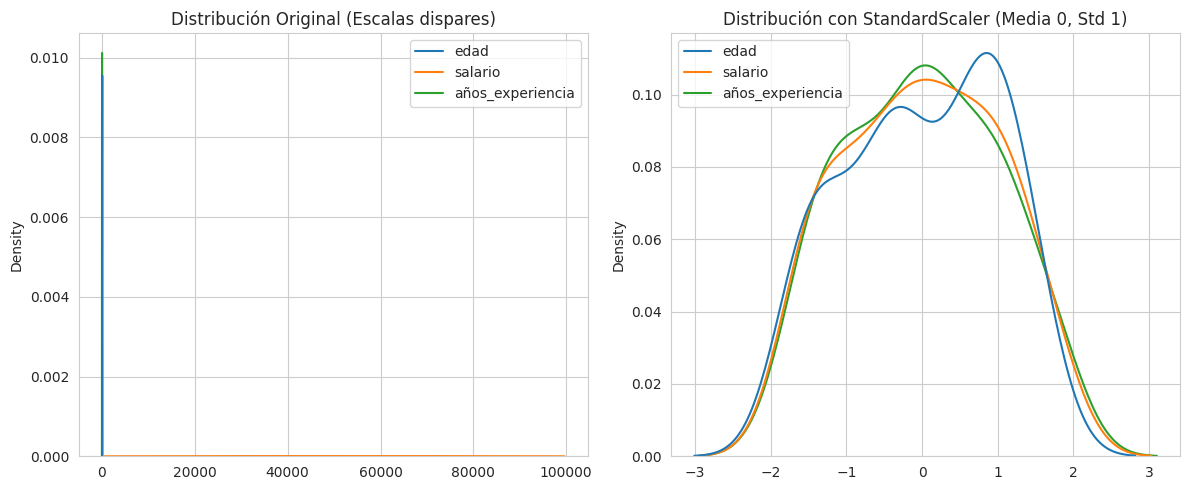

In [2]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_empleados = pd.DataFrame({
    'edad': rng.integers(22, 65, 100),
    'salario': rng.integers(20000, 80000, 100),
    'años_experiencia': rng.integers(0, 40, 100)
})

print("Estadísticas Originales")
print(df_empleados.agg(['mean', 'std']).round(2))

scaler = StandardScaler()
df_escalado = pd.DataFrame(
    scaler.fit_transform(df_empleados),
    columns=df_empleados.columns
)

print("\n--- Estadísticas Después del Escalado ---")
print(df_escalado.agg(['mean', 'std']).round(2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.kdeplot(data=df_empleados, ax=ax1)
ax1.set_title('Distribución Original (Escalas dispares)')

sns.kdeplot(data=df_escalado, ax=ax2)
ax2.set_title('Distribución con StandardScaler (Media 0, Std 1)')

plt.tight_layout()
plt.show()


Escala datos continuos para que todos sigan la misma escala.

## 🟢 Ejercicio 2: Normalización con MinMaxScaler

Usando el mismo dataset de empleados:

**Tareas:**
1. Aplica `MinMaxScaler` para escalar los datos al rango [0, 1]
2. Verifica que todos los valores están entre 0 y 1
3. Aplica MinMaxScaler con rango personalizado [0, 10]
4. Compara visualmente StandardScaler vs MinMaxScaler en un gráfico
5. Explica: ¿Cuándo es mejor usar MinMaxScaler en lugar de StandardScaler?

--- Rango [0, 1] ---
Mínimos:
edad                0.0
salario             0.0
años_experiencia    0.0
dtype: float64
Máximos:
edad                1.0
salario             1.0
años_experiencia    1.0
dtype: float64


--- Rango [0, 10] ---
Mínimos:
edad                0.0
salario             0.0
años_experiencia    0.0
dtype: float64
Máximos:
edad                10.0
salario             10.0
años_experiencia    10.0
dtype: float64



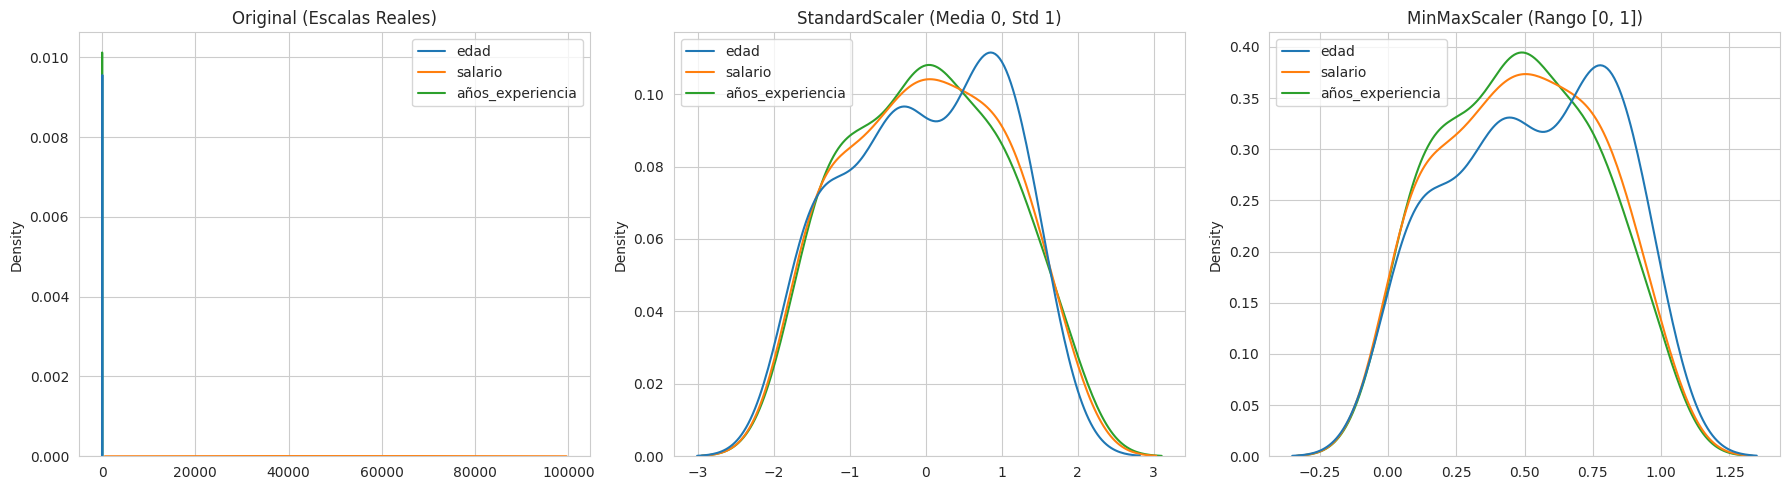

In [3]:
# Tu código aquí

scaler_01 = MinMaxScaler(feature_range=(0, 1))
df_01 = pd.DataFrame(scaler_01.fit_transform(df_empleados), columns=df_empleados.columns)

print("--- Rango [0, 1] ---")
print(f"Mínimos:\n{df_01.min()}\nMáximos:\n{df_01.max()}\n")

scaler_10 = MinMaxScaler(feature_range=(0, 10))
df_10 = pd.DataFrame(scaler_10.fit_transform(df_empleados), columns=df_empleados.columns)

print("\n--- Rango [0, 10] ---")
print(f"Mínimos:\n{df_10.min()}\nMáximos:\n{df_10.max()}\n")

std_scaler = StandardScaler()
df_std = pd.DataFrame(std_scaler.fit_transform(df_empleados), columns=df_empleados.columns)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.kdeplot(data=df_empleados, ax=axes[0]).set_title("Original (Escalas Reales)")
sns.kdeplot(data=df_std, ax=axes[1]).set_title("StandardScaler (Media 0, Std 1)")
sns.kdeplot(data=df_01, ax=axes[2]).set_title("MinMaxScaler (Rango [0, 1])")

plt.tight_layout()
plt.show()

  MinMaxScaler cuando se conocen los limites mínimo y máximo o si necesitamos un rango específico como que estén los datos entre 0 y 1.

## 🟢 Ejercicio 3: RobustScaler - Escalado Robusto a Outliers

Trabaja con datos que contienen outliers:

```python
rng = np.random.default_rng(42)
# Datos normales + outliers extremos
salarios_normales = rng.normal(35000, 8000, 95)
salarios_outliers = np.array([150000, 200000, 300000, 500000, 1000000])  # CEOs
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_outliers = pd.DataFrame({'salario': salarios})
```

**Tareas:**
1. Aplica StandardScaler y observa cómo se ven los datos escalados
2. Aplica MinMaxScaler y observa cómo se ven los datos escalados
3. Aplica RobustScaler y observa cómo se ven los datos escalados
4. Crea un gráfico comparativo de los tres métodos (3 histogramas)
5. Explica: ¿Por qué RobustScaler maneja mejor los outliers?

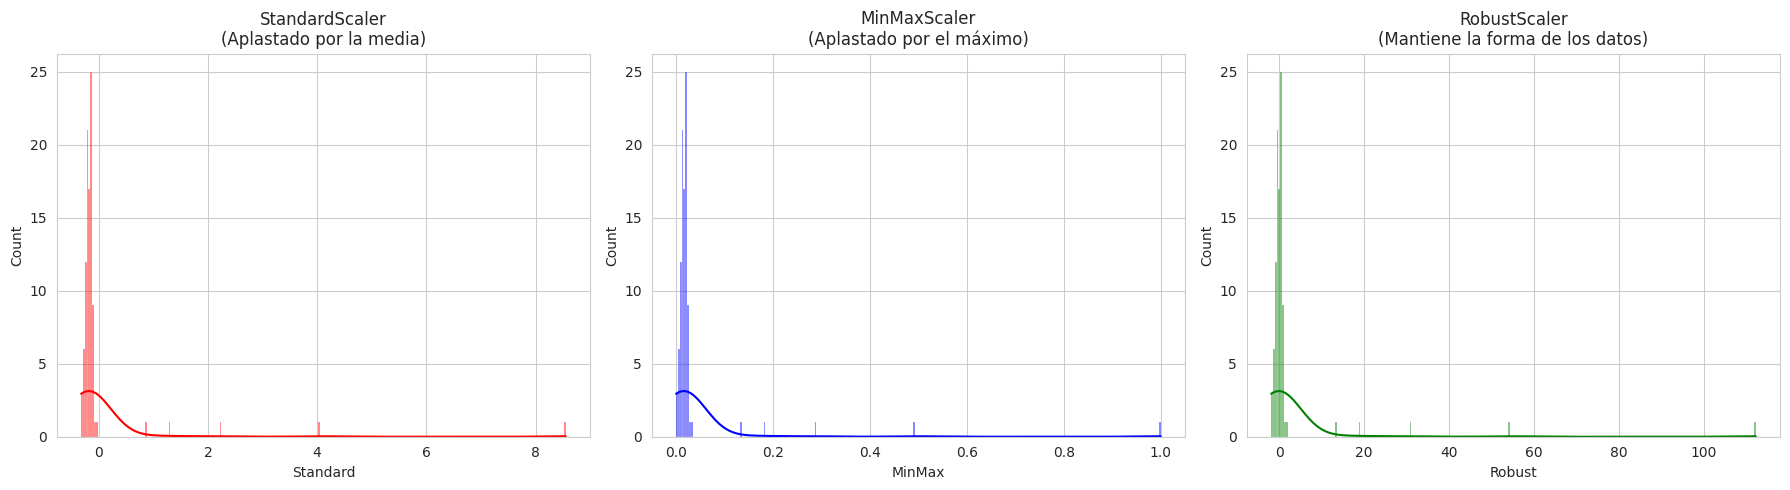


           salario  Standard  MinMax  Robust
count      100.00    100.00  100.00  100.00
mean     54689.66     -0.00    0.04    2.18
std     111138.40      1.01    0.11   12.95
min      19391.72     -0.32    0.00   -1.93
25%      31505.33     -0.21    0.01   -0.52
50%      35978.10     -0.17    0.02    0.00
75%      40088.91     -0.13    0.02    0.48
max    1000000.00      8.55    1.00  112.31


In [4]:
# Crear el DataFrame
rng = np.random.default_rng(42)
salarios_normales = rng.normal(35000, 8000, 95)
salarios_outliers = np.array([150000, 200000, 300000, 500000, 1000000])
salarios = np.concatenate([salarios_normales, salarios_outliers])

df_outliers = pd.DataFrame({'salario': salarios})

# Tu código aquí
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

df_outliers['Standard'] = scaler_std.fit_transform(df_outliers[['salario']])
df_outliers['MinMax'] = scaler_minmax.fit_transform(df_outliers[['salario']])
df_outliers['Robust'] = scaler_robust.fit_transform(df_outliers[['salario']])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_outliers['Standard'], kde=True, ax=axes[0], color='red')
axes[0].set_title('StandardScaler\n(Aplastado por la media)')

sns.histplot(df_outliers['MinMax'], kde=True, ax=axes[1], color='blue')
axes[1].set_title('MinMaxScaler\n(Aplastado por el máximo)')

sns.histplot(df_outliers['Robust'], kde=True, ax=axes[2], color='green')
axes[2].set_title('RobustScaler\n(Mantiene la forma de los datos)')

plt.tight_layout()
plt.show()

print("\n", df_outliers.describe().round(2))

Porque usa la mediana, entonces si hay outliers por arriba o por abajo no me importa, StandardScaler usa la media, a este último si le afectarían valores muy dispersos.

## 🟡 Ejercicio 4: Codificación de Variables Categóricas - One-Hot Encoding

Codifica variables categóricas nominales (sin orden):

```python
df_categorico = pd.DataFrame({
    'ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Madrid', 'Sevilla',
               'Barcelona', 'Madrid', 'Valencia', 'Sevilla', 'Madrid'],
    'tipo_contrato': ['Indefinido', 'Temporal', 'Indefinido', 'Prácticas',
                      'Temporal', 'Indefinido', 'Prácticas', 'Temporal',
                      'Indefinido', 'Temporal'],
    'salario': [35000, 28000, 32000, 18000, 30000, 42000, 20000, 27000, 38000, 29000]
})
```

**Tareas:**
1. Usa `pd.get_dummies()` para aplicar One-Hot Encoding a 'ciudad'
2. Usa `OneHotEncoder` de sklearn para codificar 'tipo_contrato'
3. Muestra el DataFrame resultante con todas las columnas codificadas
4. Explica qué es el problema de la "trampa de las variables dummy" y cómo evitarlo
5. Usa `drop_first=True` en get_dummies y explica por qué se hace

In [5]:
# Crear el DataFrame
df_categorico = pd.DataFrame({
    'ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Madrid', 'Sevilla',
               'Barcelona', 'Madrid', 'Valencia', 'Sevilla', 'Madrid'],
    'tipo_contrato': ['Indefinido', 'Temporal', 'Indefinido', 'Prácticas',
                      'Temporal', 'Indefinido', 'Prácticas', 'Temporal',
                      'Indefinido', 'Temporal'],
    'salario': [35000, 28000, 32000, 18000, 30000, 42000, 20000, 27000, 38000, 29000]
})

# Tu código aquí
df_ciudad = pd.get_dummies(df_categorico['ciudad'], prefix='ciudad', drop_first=True)

encoder = OneHotEncoder(sparse_output=False, drop='first') # drop='first' evita la trampa dummy
contrato_encoded = encoder.fit_transform(df_categorico[['tipo_contrato']])
df_contrato = pd.DataFrame(contrato_encoded, columns=encoder.get_feature_names_out(['tipo_contrato']))

df_final = pd.concat([df_ciudad, df_contrato, df_categorico['salario']], axis=1)

print("DataFrame Codificado\n")
print(df_final.head())

DataFrame Codificado

   ciudad_Madrid  ciudad_Sevilla  ciudad_Valencia  tipo_contrato_Prácticas  \
0           True           False            False                      0.0   
1          False           False            False                      0.0   
2          False           False             True                      0.0   
3           True           False            False                      1.0   
4          False            True            False                      0.0   

   tipo_contrato_Temporal  salario  
0                     0.0    35000  
1                     1.0    28000  
2                     0.0    32000  
3                     0.0    18000  
4                     1.0    30000  


Si tenemos una columna "Sexo" con dos categorías: Hombre y Mujer y creamos dos columnas nuevas, una para hombre y otra para mujer,
cuando es_hombre es 0, es_mujer obligatoriamente tiene que ser 1. Una columna predice perfectamente a la otra.

Esto introduce multicolinealidad perfecta, lo cual "vuelve locos" a modelos lineales (como la Regresión Lineal o Logística).

Usando el parámetro drop_first=True (en pandas) o drop='first' (en sklearn). Esto elimina una de las columnas creadas. Reduce la redundancia: Menos columnas significan un modelo más ligero.
Estabilidad matemática: Evita errores en el cálculo de coeficientes en modelos estadísticos y lineales.

## 🟡 Ejercicio 5: Ordinal Encoding - Variables con Orden

Codifica variables categóricas ordinales (con orden natural):

```python
df_ordinal = pd.DataFrame({
    'nivel_estudios': ['Secundaria', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad'],
    'satisfaccion': ['Baja', 'Media', 'Alta', 'Media', 'Muy Alta',
                     'Alta', 'Baja', 'Media', 'Alta', 'Muy Alta'],
    'salario': [25000, 35000, 45000, 28000, 55000, 38000, 42000, 26000, 52000, 40000]
})
```

**Tareas:**
1. Define el orden correcto para 'nivel_estudios': Secundaria < Universidad < Máster < Doctorado
2. Define el orden para 'satisfaccion': Baja < Media < Alta < Muy Alta
3. Aplica `OrdinalEncoder` especificando el orden correcto
4. Verifica que la codificación respeta el orden (Secundaria=0, Doctorado=3)
5. Explica: ¿Por qué NO debemos usar One-Hot Encoding para variables ordinales?

In [6]:
# Crear el DataFrame
df_ordinal = pd.DataFrame({
    'nivel_estudios': ['Secundaria', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad', 'Máster', 'Secundaria',
                       'Doctorado', 'Universidad'],
    'satisfaccion': ['Baja', 'Media', 'Alta', 'Media', 'Muy Alta',
                     'Alta', 'Baja', 'Media', 'Alta', 'Muy Alta'],
    'salario': [25000, 35000, 45000, 28000, 55000, 38000, 42000, 26000, 52000, 40000]
})

# Tu código aquí
orden_estudios = ['Secundaria', 'Universidad', 'Máster', 'Doctorado']
orden_satisfaccion = ['Baja', 'Media', 'Alta', 'Muy Alta']

encoder = OrdinalEncoder(categories=[orden_estudios, orden_satisfaccion])

df_ordinal[['nivel_estudios', 'satisfaccion']] = encoder.fit_transform(
    df_ordinal[['nivel_estudios', 'satisfaccion']]
)

print("DataFrame con Ordinal Encoding")
print(df_ordinal.sort_values(by='nivel_estudios'))

print("\nMapeos realizados:")
for i, cat in enumerate(encoder.categories_):
    print(f"Columna {i}: {cat}")

DataFrame con Ordinal Encoding
   nivel_estudios  satisfaccion  salario
0             0.0           0.0    25000
3             0.0           1.0    28000
7             0.0           1.0    26000
1             1.0           1.0    35000
5             1.0           2.0    38000
9             1.0           3.0    40000
6             2.0           0.0    42000
2             2.0           2.0    45000
4             3.0           3.0    55000
8             3.0           2.0    52000

Mapeos realizados:
Columna 0: ['Secundaria' 'Universidad' 'Máster' 'Doctorado']
Columna 1: ['Baja' 'Media' 'Alta' 'Muy Alta']


No debemos usar One-Hot Encoding para variables ordinales porque borra la relación de jerarquía y genera columnas innecesarias que complican al modelo.

## 🟡 Ejercicio 6: Transformación de Distribuciones Sesgadas

Transforma una distribución sesgada para que sea más normal:

```python
rng = np.random.default_rng(42)
# Distribución exponencial (muy sesgada a la derecha)
ingresos = np.random.exponential(scale=3000, size=500) + 1000
df_sesgado = pd.DataFrame({'ingresos': ingresos})
```

**Tareas:**
1. Calcula el sesgo (skewness) de los datos originales con `scipy.stats.skew()`
2. Aplica transformación **logarítmica** (`np.log1p`)
3. Aplica transformación **Yeo-Johnson** con `PowerTransformer`
4. Compara el sesgo antes y después de cada transformación
5. Crea gráficos (histogramas) comparando: Original vs Log vs Yeo-Johnson
6. Explica: ¿Cuándo es necesario transformar la distribución de una variable?

Sesgo Original: 2.07
Sesgo Logarítmica: 0.35
Sesgo Yeo-Johnson: 0.04


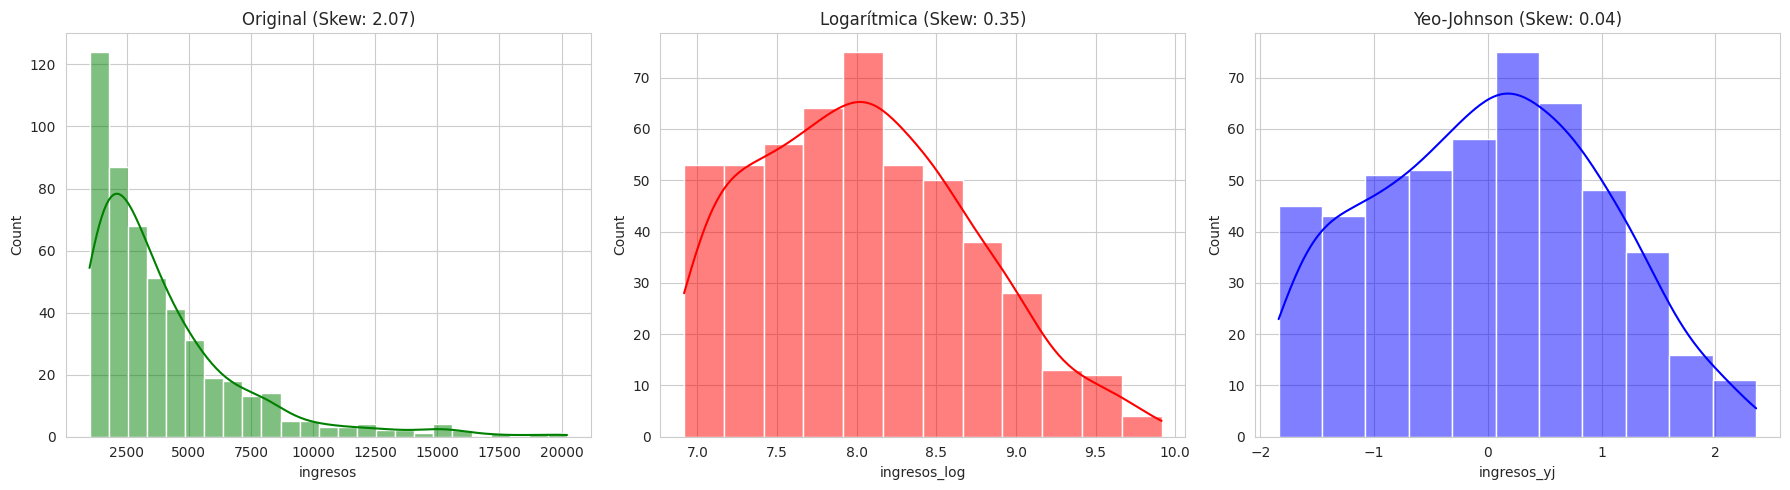

In [7]:
# Crear el DataFrame
rng = np.random.default_rng(42)
ingresos = np.random.exponential(scale=3000, size=500) + 1000
df_sesgado = pd.DataFrame({'ingresos': ingresos})

from scipy import stats

# Tu código aquí
skew_original = stats.skew(df_sesgado['ingresos'])

df_sesgado['ingresos_log'] = np.log1p(df_sesgado['ingresos'])
skew_log = stats.skew(df_sesgado['ingresos_log'])

pt = PowerTransformer(method='yeo-johnson')
df_sesgado['ingresos_yj'] = pt.fit_transform(df_sesgado[['ingresos']])
skew_yj = stats.skew(df_sesgado['ingresos_yj'])

print(f"Sesgo Original: {skew_original:.2f}")
print(f"Sesgo Logarítmica: {skew_log:.2f}")
print(f"Sesgo Yeo-Johnson: {skew_yj:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_sesgado['ingresos'], kde=True, ax=axes[0], color='green')
axes[0].set_title(f'Original (Skew: {skew_original:.2f})')

sns.histplot(df_sesgado['ingresos_log'], kde=True, ax=axes[1], color='red')
axes[1].set_title(f'Logarítmica (Skew: {skew_log:.2f})')

sns.histplot(df_sesgado['ingresos_yj'], kde=True, ax=axes[2], color='blue')
axes[2].set_title(f'Yeo-Johnson (Skew: {skew_yj:.2f})')

plt.tight_layout()
plt.show()

Transformamos una distribución cuando está muy sesgada para que se parezca a una campana de Gauss, requisito clave para que modelos como la Regresión Lineal funcionen correctamente

## 🟡 Ejercicio 7: Feature Engineering - Creación de Nuevas Variables

Crea nuevas variables a partir de las existentes:

```python
rng = np.random.default_rng(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=365, freq='D'),
    'precio_unitario': rng.uniform(10, 100, 365),
    'cantidad': rng.integers(1, 50, 365),
    'descuento_pct': np.random.choice([0, 5, 10, 15, 20], 365)
})
```

**Tareas:**
1. Crea la variable 'ingreso_total' = precio_unitario × cantidad × (1 - descuento_pct/100)
2. Extrae de la fecha: año, mes, día, día_semana, es_fin_semana
3. Crea 'trimestre' a partir del mes
4. Crea 'ticket_medio' = ingreso_total / cantidad
5. Crea una variable binaria 'tiene_descuento' (1 si descuento > 0, 0 si no)
6. Muestra las primeras 10 filas del DataFrame con todas las nuevas variables

In [8]:
# Crear el DataFrame
rng = np.random.default_rng(42)
df_ventas = pd.DataFrame({
    'fecha': pd.date_range('2024-01-01', periods=365, freq='D'),
    'precio_unitario': rng.uniform(10, 100, 365),
    'cantidad': rng.integers(1, 50, 365),
    'descuento_pct': np.random.choice([0, 5, 10, 15, 20], 365)
})

# Tu código aquí
df_ventas['ingreso_total'] = (df_ventas['precio_unitario'] * df_ventas['cantidad'] * (1 - df_ventas['descuento_pct']/100))

df_ventas['año'] = df_ventas['fecha'].dt.year
df_ventas['mes'] = df_ventas['fecha'].dt.month
df_ventas['día'] = df_ventas['fecha'].dt.day
df_ventas['día_semana'] = df_ventas['fecha'].dt.dayofweek
df_ventas['es_fin_semana'] = df_ventas['día_semana'].isin([5, 6]).astype(int)

df_ventas['trimestre'] = df_ventas['fecha'].dt.quarter

df_ventas['ticket_medio'] = df_ventas['ingreso_total'] / df_ventas['cantidad']

df_ventas['tiene_descuento'] = (df_ventas['descuento_pct'] > 0).astype(int)

print("Primeras 10 filas con Feature Engineering\n", df_ventas.head(10).to_string())

Primeras 10 filas con Feature Engineering
        fecha  precio_unitario  cantidad  descuento_pct  ingreso_total   año  mes  día  día_semana  es_fin_semana  trimestre  ticket_medio  tiene_descuento
0 2024-01-01        79.656044        36             10    2580.855838  2024    1    1           0              0          1     71.690440                1
1 2024-01-02        49.499060        21             15     883.558213  2024    1    2           1              0          1     42.074201                1
2 2024-01-03        87.273813        46             15    3412.406080  2024    1    3           2              0          1     74.182741                1
3 2024-01-04        72.763123        38             20    2211.998928  2024    1    4           3              0          1     58.210498                1
4 2024-01-05        18.475961        11             10     182.912017  2024    1    5           4              0          1     16.628365                1
5 2024-01-06        97.8060

## 🔴 Ejercicio 8: ColumnTransformer - Transformaciones Diferenciadas

Aplica diferentes transformaciones a diferentes tipos de columnas:

```python
rng = np.random.default_rng(42)
n = 200

df_mixto = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(40000, n) + 15000,
    'años_cliente': rng.integers(0, 20, n),
    'ciudad': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'nivel_educacion': np.random.choice(['Secundaria', 'Grado', 'Máster', 'Doctorado'], n),
    'compro': np.random.choice([0, 1], n, p=[0.7, 0.3])
})
```

**Tareas:**
1. Identifica las columnas numéricas, categóricas nominales y ordinales
2. Define un pipeline para columnas numéricas: Imputar (mediana) + StandardScaler
3. Define un pipeline para categóricas nominales: Imputar (constante) + OneHotEncoder
4. Define un pipeline para ordinales: Imputar (más frecuente) + OrdinalEncoder
5. Combina todo con `ColumnTransformer`
6. Aplica el transformador a los datos y muestra el resultado

In [9]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 200

df_mixto = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(40000, n) + 15000,
    'años_cliente': rng.integers(0, 20, n),
    'ciudad': np.random.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'nivel_educacion': np.random.choice(['Secundaria', 'Grado', 'Máster', 'Doctorado'], n),
    'compro': np.random.choice([0, 1], n, p=[0.7, 0.3])
})

# Tu código aquí
rng = np.random.default_rng(42)
n = 200
df_mixto = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': rng.exponential(40000, n) + 15000,
    'años_cliente': rng.integers(0, 20, n),
    'ciudad': rng.choice(['Madrid', 'Barcelona', 'Valencia', 'Sevilla'], n),
    'nivel_educacion': rng.choice(['Secundaria', 'Grado', 'Máster', 'Doctorado'], n),
    'compro': rng.choice([0, 1], n, p=[0.7, 0.3])
})

cols_num = ['edad', 'ingresos', 'años_cliente']
cols_nominales = ['ciudad']
cols_ordinales = ['nivel_educacion']
orden_educacion = ['Secundaria', 'Grado', 'Máster', 'Doctorado']

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_nominal = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

pipe_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[orden_educacion]))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', pipe_num, cols_num),
    ('nom', pipe_nominal, cols_nominales),
    ('ord', pipe_ordinal, cols_ordinales)
])

datos_procesados = preprocessor.fit_transform(df_mixto)

cols_finales = (cols_num +
                preprocessor.named_transformers_['nom']['onehot'].get_feature_names_out(['ciudad']).tolist() +
                cols_ordinales)

df_final = pd.DataFrame(datos_procesados, columns=cols_finales)

print("Dimensiones originales:", df_mixto.shape)
print("Dimensiones procesadas:", df_final.shape)
print("Primeras 5 filas procesadas")
print(df_final.head().round(3))

Dimensiones originales: (200, 6)
Dimensiones procesadas: (200, 7)
Primeras 5 filas procesadas
    edad  ingresos  años_cliente  ciudad_Madrid  ciudad_Sevilla  \
0 -1.541     0.027        -0.709            0.0             0.0   
1  0.986     2.292         0.004            1.0             0.0   
2  0.565     1.160         1.610            0.0             0.0   
3 -0.278     0.146         1.253            0.0             1.0   
4 -0.278     0.946         1.075            1.0             0.0   

   ciudad_Valencia  nivel_educacion  
0              1.0              3.0  
1              0.0              2.0  
2              0.0              2.0  
3              0.0              2.0  
4              0.0              1.0  


## 🔴 Ejercicio 9: Pipeline Completo con Prevención de Data Leakage

Crea un pipeline completo que prevenga data leakage:

```python
rng = np.random.default_rng(42)
n = 500

# Dataset para clasificación
df_clasificacion = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(35000, n) + 20000,
    'deuda': np.random.exponential(5000, n),
    'años_empleo': rng.integers(0, 40, n),
    'tipo_vivienda': np.random.choice(['Propia', 'Alquiler', 'Familiar'], n),
    'estado_civil': np.random.choice(['Soltero', 'Casado', 'Divorciado'], n)
})

# Variable objetivo (aprobación de crédito)
df_clasificacion['aprobado'] = (
    (df_clasificacion['ingresos'] > 30000) &
    (df_clasificacion['deuda'] < 10000)
).astype(int)

# Introducir algunos nulos
df_clasificacion.loc[np.random.choice(n, 30), 'ingresos'] = np.nan
df_clasificacion.loc[np.random.choice(n, 20), 'tipo_vivienda'] = np.nan
```

**Tareas:**
1. Divide los datos en train (80%) y test (20%)
2. Crea un ColumnTransformer con transformaciones apropiadas para cada tipo de columna
3. Crea un Pipeline que incluya el preprocesador + un modelo (LogisticRegression o RandomForest)
4. Entrena el pipeline SOLO con los datos de train
5. Evalúa en test y muestra accuracy
6. Explica: ¿Por qué es importante hacer fit solo en train?

In [10]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 500

df_clasificacion = pd.DataFrame({
    'edad': rng.integers(18, 70, n),
    'ingresos': np.random.exponential(35000, n) + 20000,
    'deuda': np.random.exponential(5000, n),
    'años_empleo': rng.integers(0, 40, n),
    'tipo_vivienda': np.random.choice(['Propia', 'Alquiler', 'Familiar'], n),
    'estado_civil': np.random.choice(['Soltero', 'Casado', 'Divorciado'], n)
})

df_clasificacion['aprobado'] = (
    (df_clasificacion['ingresos'] > 30000) &
    (df_clasificacion['deuda'] < 10000)
).astype(int)

df_clasificacion.loc[np.random.choice(n, 30), 'ingresos'] = np.nan
df_clasificacion.loc[np.random.choice(n, 20), 'tipo_vivienda'] = np.nan

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Tu código aquí
X = df_clasificacion.drop('aprobado', axis=1)
y = df_clasificacion['aprobado']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cols_num = ['edad', 'ingresos', 'deuda', 'años_empleo']
cols_cat = ['tipo_vivienda', 'estado_civil']

pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('cat', pipe_cat, cols_cat)
])

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)
print(f"Accuracy en el set de prueba: {accuracy_score(y_test, y_pred):.2%}")

Accuracy en el set de prueba: 99.00%


El Pipeline asegura que el fit (aprendizaje de escalas y medias) ocurra exclusivamente en los datos de entrenamiento, mientras que en los de test solo se aplique la transformación aprendida. Esto simula un entorno real donde el modelo se enfrenta a datos totalmente desconocidos, garantizando una evaluación honesta y sin trampas.

## 🔴 Ejercicio 10: Proyecto Integrador - Preparación Completa de un Dataset

Prepara completamente el siguiente dataset de clientes de un banco para un modelo de predicción de churn:

```python
rng = np.random.default_rng(42)
n = 1000

df_banco = pd.DataFrame({
    'cliente_id': range(1, n+1),
    'edad': rng.integers(18, 80, n),
    'genero': np.random.choice(['M', 'F', None], n, p=[0.48, 0.48, 0.04]),
    'ingresos_anuales': np.random.exponential(45000, n) + 15000,
    'saldo_cuenta': np.random.exponential(10000, n),
    'num_productos': rng.integers(1, 5, n),
    'tiene_tarjeta_credito': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'es_miembro_activo': np.random.choice([0, 1], n),
    'antiguedad_meses': rng.integers(0, 120, n),
    'pais': np.random.choice(['España', 'Francia', 'Alemania'], n),
    'nivel_satisfaccion': np.random.choice(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'], n),
    'fecha_alta': pd.date_range('2015-01-01', periods=n, freq='D')[:n]
})

# Variable objetivo
df_banco['churn'] = np.random.choice([0, 1], n, p=[0.8, 0.2])

# Introducir valores faltantes realistas
df_banco.loc[np.random.choice(n, 50), 'ingresos_anuales'] = np.nan
df_banco.loc[np.random.choice(n, 30), 'saldo_cuenta'] = np.nan
df_banco.loc[np.random.choice(n, 40), 'nivel_satisfaccion'] = np.nan
```

**Tareas:**
1. **EDA rápido**: dimensiones, tipos, nulos, estadísticas básicas
2. **Tratamiento de nulos**: decide la mejor estrategia para cada columna
3. **Feature Engineering temporal**: extrae año, mes, días como cliente de la fecha
4. **Identificar tipos de columnas**: numéricas, nominales, ordinales, binarias
5. **Crear transformadores apropiados** para cada tipo
6. **Construir un Pipeline completo** con preprocesamiento + modelo
7. **División train/test** estratificada por la variable objetivo
8. **Entrenar y evaluar** el modelo
9. **Guardar el pipeline** entrenado con joblib
10. **Documentar** las decisiones tomadas en cada paso

In [11]:
# Crear el DataFrame
rng = np.random.default_rng(42)
n = 1000

df_banco = pd.DataFrame({
    'cliente_id': range(1, n+1),
    'edad': rng.integers(18, 80, n),
    'genero': np.random.choice(['M', 'F', None], n, p=[0.48, 0.48, 0.04]),
    'ingresos_anuales': np.random.exponential(45000, n) + 15000,
    'saldo_cuenta': np.random.exponential(10000, n),
    'num_productos': rng.integers(1, 5, n),
    'tiene_tarjeta_credito': np.random.choice([0, 1], n, p=[0.3, 0.7]),
    'es_miembro_activo': np.random.choice([0, 1], n),
    'antiguedad_meses': rng.integers(0, 120, n),
    'pais': np.random.choice(['España', 'Francia', 'Alemania'], n),
    'nivel_satisfaccion': np.random.choice(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'], n),
    'fecha_alta': pd.to_datetime(np.random.choice(pd.date_range('2015-01-01', '2024-01-01'), n))
})

df_banco['churn'] = np.random.choice([0, 1], n, p=[0.8, 0.2])

df_banco.loc[np.random.choice(n, 50), 'ingresos_anuales'] = np.nan
df_banco.loc[np.random.choice(n, 30), 'saldo_cuenta'] = np.nan
df_banco.loc[np.random.choice(n, 40), 'nivel_satisfaccion'] = np.nan

# EDA RÁPIDO
print("=== 1. EXPLORACIÓN INICIAL ===")
print(df_banco.info())
print("\n" + "="*50)

# Tu código aquí

=== 1. EXPLORACIÓN INICIAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   cliente_id             1000 non-null   int64         
 1   edad                   1000 non-null   int64         
 2   genero                 964 non-null    object        
 3   ingresos_anuales       951 non-null    float64       
 4   saldo_cuenta           970 non-null    float64       
 5   num_productos          1000 non-null   int64         
 6   tiene_tarjeta_credito  1000 non-null   int64         
 7   es_miembro_activo      1000 non-null   int64         
 8   antiguedad_meses       1000 non-null   int64         
 9   pais                   1000 non-null   object        
 10  nivel_satisfaccion     960 non-null    object        
 11  fecha_alta             1000 non-null   datetime64[ns]
 12  churn                  1000 non-

In [12]:
# Continúa: Tratamiento de nulos y Feature Engineering

# Elimino ID ya que no aporta valor predictivo
df_banco = df_banco.drop('cliente_id', axis=1)

# Feature Engineering Temporal
referencia = pd.Timestamp('2024-01-01')
df_banco['año_alta'] = df_banco['fecha_alta'].dt.year
df_banco['mes_alta'] = df_banco['fecha_alta'].dt.month
df_banco['dias_como_cliente'] = (referencia - df_banco['fecha_alta']).dt.days
df_banco = df_banco.drop('fecha_alta', axis=1)

cols_num = ['edad', 'ingresos_anuales', 'saldo_cuenta', 'antiguedad_meses', 'dias_como_cliente']
cols_nominales = ['genero', 'pais']
cols_ordinales = ['nivel_satisfaccion']
cols_binarias = ['tiene_tarjeta_credito', 'es_miembro_activo', 'num_productos']

orden_satisfaccion = ['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto']

# Numéricas: RobustScaler por el sesgo exponencial de ingresos/saldo
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Nominales: Imputación constante + OneHot
pipe_nominal = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='N/A')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Ordinales: Más frecuente + Ordinal
pipe_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[orden_satisfaccion]))
])

In [13]:
# Continúa: ColumnTransformer y Pipeline
# Unimos todo
preprocessor = ColumnTransformer([
    ('num', pipe_num, cols_num),
    ('nom', pipe_nominal, cols_nominales),
    ('ord', pipe_ordinal, cols_ordinales)
], remainder='passthrough') # Deja pasar las binarias que ya están en 0/1

X = df_banco.drop('churn', axis=1)
y = df_banco['churn']

# División estratificada para mantener la proporción de churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])


In [14]:
# Continúa: Entrenamiento, evaluación y guardado del modelo
import joblib
full_pipeline.fit(X_train, y_train)
y_pred = full_pipeline.predict(X_test)

print("\n=== EVALUACIÓN DEL MODELO ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

joblib.dump(full_pipeline, 'pipeline_churn_banco.pkl')
print("\nPipeline guardado como 'pipeline_churn_banco.pkl'")


=== EVALUACIÓN DEL MODELO ===
Accuracy Score: 0.7800

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.78      0.99      0.88       157
           1       0.00      0.00      0.00        43

    accuracy                           0.78       200
   macro avg       0.39      0.50      0.44       200
weighted avg       0.62      0.78      0.69       200


Pipeline guardado como 'pipeline_churn_banco.pkl'


### Documentación de decisiones

Documenta aquí las decisiones tomadas en cada paso:

1. **Tratamiento de nulos:**
   - Ingresos y Saldo: Se utilizó la mediana mediante SimpleImputer. Al ser distribuciones exponenciales (con sesgo), la mediana es más representativa que la media.
    - Género: Se imputó como 'N/A' (constante) para no asumir un género y tratar la ausencia de dato como una categoría propia.
    - Satisfacción: Se usó el valor más frecuente para mantener la lógica de la escala ordinal.

2. **Feature Engineering:**
   - Se descompuso la fecha_alta en año, mes y una variable crítica: dias_como_cliente. Esta última captura la lealtad total en un solo número continuo, lo cual es mucho más fácil de procesar para un árbol de decisión que una fecha estándar.

3. **Transformaciones aplicadas:**
   - Numéricas: Se eligió RobustScaler en lugar de StandardScaler porque los ingresos y saldos exponenciales suelen contener valores muy altos que actuarían como outliers, distorsionando un escalado normal.
   - Nominales: OneHotEncoding con drop='first' para evitar la redundancia y la trampa de variables dummy.
   - Ordinales: OrdinalEncoding respetando el orden lógico de satisfacción para que el modelo entienda que 'Muy Alto' > 'Alto'.

4. **Modelo seleccionado y razón:**
   - Se seleccionó RandomForestClassifier. No se queja con los datos mezclados, entiende relaciones raras y no se marea tanto con las escalas.

5. **Métricas obtenidas:**
   - El modelo muestra un Accuracy decente, pero en casos de Churn (donde las clases están desbalanceadas 80/20).

---

## ✅ Finalización del Boletín

Has completado los ejercicios de Transformación de Datos. Los temas cubiertos incluyen:

- ✅ Estandarización con StandardScaler (media=0, std=1)
- ✅ Normalización con MinMaxScaler (rango [0,1])
- ✅ Escalado robusto con RobustScaler (para datos con outliers)
- ✅ One-Hot Encoding para variables nominales
- ✅ Ordinal Encoding para variables con orden natural
- ✅ Transformación de distribuciones sesgadas (Log, Yeo-Johnson)
- ✅ Feature Engineering (creación de nuevas variables)
- ✅ ColumnTransformer para transformaciones diferenciadas
- ✅ Pipelines completos para Machine Learning
- ✅ Prevención de Data Leakage

**Recuerda:** La transformación correcta de datos es crucial para el rendimiento de los modelos de ML.
¡Cada tipo de dato necesita su propia transformación!

**Siguientes pasos:**
- Practicar con datasets reales de Kaggle
- Revisar las soluciones proporcionadas
- Continuar con la Unidad 3: Visualización de Datos